# 基于 dataset1 拟合背景的随机目标生成检查

本笔记本每次从 `fit/dataset1_background_model.npz` 读取背景模型，生成一段 300 帧的二值背景，随后随机生成并注入一条带漏检的目标航迹。

- 每帧间隔为 $0.05\,\mathrm{s}$；速度上限 $340\,\mathrm{m/s}$，因此轨迹每帧最多移动 $17\,\mathrm{m}$。
- 潜在轨迹由平滑加速度递推得到，可为直线或轻微弯曲曲线。
- 目标只在其轨迹位置额外制造 `1`；漏检由注入概率自然产生。
- 每次重新执行“生成并注入目标”单元，都会得到一个新的背景随机实现和一个新的目标。

## 目标与背景的二值叠加规则

设第 $t$ 帧目标测距 bin 为 $r_t$。当前实现使用本次背景场景恢复出的**参考距离响应率** $p_{\mathrm{bg}}(r)$ 计算目标注入概率；它只随距离变化，不随帧级亮暗调节 $c_t$ 改变。实际生成的二值背景记为 $B_{t,r}\in\{0,1\}$。

先由目标相对背景的响应倍率 $\kappa$ 得到目标位置的候选响应值：

$$
p_{\mathrm{candidate},t}(r_t)
=
\max\big\{
p_{\mathrm{bg}}(r_t),
\kappa p_{\mathrm{bg}}(r_t)
\big\}.
$$

将其换算为 “除背景外，额外注入一个 1” 的原始概率，并进行上下限裁剪，得到目标点注入概率：

$$
q_t
=
\operatorname{clip}\left(
\frac{
p_{\mathrm{candidate},t}(r_t)
-
p_{\mathrm{bg}}(r_t)
}{
1-p_{\mathrm{bg}}(r_t)
},
q_{\min},q_{\max}
\right).
$$

这个被裁剪的分式是在反解二值叠加后的总响应概率。分子表示目标位置还缺少的响应概率，分母表示背景仍为 0、可额外注入 1 的概率。这样设计的目的，是在结合已有背景后保持目标位置的设定总响应概率

最后独立生成目标注入事件，并与已经生成的背景做逻辑 OR：

$$
Z_t\sim\operatorname{Bernoulli}(q_t),
\qquad
Y_{t,r_t}=B_{t,r_t}\lor Z_t.
$$

叠加后的理论响应率为 $p_{\mathrm{bg}}(r_t)+[1-p_{\mathrm{bg}}(r_t)]q_t$，不考虑裁剪时等于 $p_{\mathrm{candidate},t}(r_t)$


## 1. 导入依赖并读取拟合模型

In [84]:
# 导入数值计算、绘图与项目中的背景生成函数。
from pathlib import Path
import sys

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/home/pc5090/Code/github/LineTracker")
FIT_PATH = PROJECT_ROOT / "data/synthetic/fit/dataset1_background_model.npz"

# 使 Notebook 可从任意工作目录导入项目中的生成器。
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data.synthetic.generate_dataset1 import generate_background, load_model

# 中文字体可用时优先使用；若环境没有该字体会自动回退。
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

model = load_model(FIT_PATH)
RANGE_BINS = int(model["range_bins"])
PROFILE_WIDTH_M = int(model["profile_width_m"])
FRAME_INTERVAL_S = 0.05 # 相邻两帧激光测量之间的时间间隔为 0.05s

print(f"已读取模型：{FIT_PATH.name}")
print(f"距离单元数：{RANGE_BINS:,}；距离分组宽度：{PROFILE_WIDTH_M} m")
print("稳定拟合样本：", ", ".join(model["sample_ids"].tolist()))

已读取模型：dataset1_background_model.npz
距离单元数：300,000；距离分组宽度：1000 m
稳定拟合样本： dataset1/1, dataset1/3, dataset1/4, dataset1/6, dataset1/7, dataset1/9, dataset1/10


## 2. 设置背景场景与目标参数

In [85]:
# 唯一调参框：修改此字典后，运行后面的 run_target_demo 调用单元即可得到新的随机样本和三张图。
# 种子为 None 时，每次运行都会生成新的随机背景与目标；填写整数可复现。
DEMO_CONFIG = {
    "background_seed": None,  # 背景随机种子；None 时每次自动随机，整数时可复现。
    "target_seed": None,      # 目标航迹与响应随机种子；None 时每次自动随机。
    "background_knobs": {  # 均为拟合模型定义的 [-1, 1] 旋钮；0 表示中点。
        "level": 0.0,       # 整体背景响应率高低。
        "decay": 0.0,       # 背景响应率随距离衰减的形状。
        "near_field": 0.0,  # 近场（约 0–10 km）背景的额外变化。
        "gain": 0.0,        # 帧间整体亮暗波动，即目标 Fano factor。
        "cluster": 0.0,     # 同帧内 1–3 m 相邻 bin 的局部聚集强度。
    },
    "target_config": {
        "frames": 300,                     # 帧数；0.05 s/帧时对应 15 s。
        "range_min_m": 10_000.0,           # 潜在轨迹允许的最小距离（m）。
        "range_max_m": 290_000.0,          # 潜在轨迹允许的最大距离（m）。
        "max_speed_mps": 340.0,            # 速度绝对值上限（m/s），即最多 17 m/帧。
        "max_acceleration_mps2": 6.0,      # 加速度尺度上限（m/s²），还会乘 curve_strength。
        "curve_strength": 0.35,            # 曲率强度；0 时为严格直线。
        "smooth_window_frames": 31,        # 加速度移动平均窗口（帧）；越大曲线越平滑。
        "measurement_jitter_std_m": 1.0,   # 目标响应落入 1 m bin 的测距抖动标准差（m）。
        "response_multiplier": 30.0,       # 倍率机制中的目标响应率相对背景倍率 kappa。
        "min_injection_probability": 0.60, # 实际目标响应（红点）的逐帧概率下限。
        "max_injection_probability": 0.95, # 实际目标响应（红点）的逐帧概率上限。
    },
    "margin_m": 5_000.0,             # 两张局部时距图在航迹两端保留的距离余量。
    "background_point_size": 3,       # 局部时距图中方形二值响应点的面积（pt²）。
}

display(pd.DataFrame([
    {"参数组": "背景旋钮", "参数": key, "取值": value}
    for key, value in DEMO_CONFIG["background_knobs"].items()
]))

,参数组,参数,取值
0,背景旋钮,level,0.0
1,背景旋钮,decay,0.0
2,背景旋钮,near_field,0.0
3,背景旋钮,gain,0.0
4,背景旋钮,cluster,0.0


## 3. 生成受速度与曲率约束的随机目标

In [98]:
def generate_target(
    p_bg_1m: np.ndarray,
    *,
    frames: int,
    range_min_m: float,
    range_max_m: float,
    max_speed_mps: float,
    max_acceleration_mps2: float,
    curve_strength: float,
    smooth_window_frames: int,
    measurement_jitter_std_m: float,
    response_multiplier: float,
    min_injection_probability: float,
    max_injection_probability: float,
    rng: np.random.Generator,
) -> dict:
    # 生成潜在航迹和稀疏目标命中；不在此函数内分配完整目标矩阵。
    p_bg_1m = np.asarray(p_bg_1m, dtype=np.float64)
    if p_bg_1m.shape != (RANGE_BINS,):
        raise ValueError("p_bg_1m 的长度必须等于 RANGE_BINS。")
    if not 0.0 <= min_injection_probability <= max_injection_probability <= 1.0:
        raise ValueError("目标注入概率上下限必须满足 0 <= min <= max <= 1。")

    dt = FRAME_INTERVAL_S
    max_step_m = max_speed_mps * dt

    # 生成低频加速度，确保曲率连续且幅度可控。
    window = min(int(smooth_window_frames), frames)
    window = window if window % 2 == 1 else max(window - 1, 1)
    kernel = np.ones(window, dtype=np.float64) / window
    acceleration = np.convolve(rng.normal(size=frames), kernel, mode="same")
    acceleration /= max(np.max(np.abs(acceleration)), 1e-12)
    acceleration *= curve_strength * max_acceleration_mps2

    # 递推速度，并强制限制在 ±340 m/s 内。
    velocity = np.empty(frames, dtype=np.float64)
    velocity[0] = rng.uniform(-0.8 * max_speed_mps, 0.8 * max_speed_mps)
    for t in range(1, frames):
        velocity[t] = np.clip(
            velocity[t - 1] + acceleration[t - 1] * dt,
            -max_speed_mps,
            max_speed_mps,
        )

    # 先生成相对位移，再选择起点，确保整条轨迹留在设定距离范围中。
    displacement = np.r_[0.0, np.cumsum(velocity[:-1] * dt)]
    start_low = range_min_m - displacement.min()
    start_high = range_max_m - displacement.max()
    if start_low > start_high:
        raise ValueError("设定距离域无法容纳当前轨迹。")
    true_range_m = rng.uniform(start_low, start_high) + displacement

    # 测距抖动只改变落入的离散 1 m bin，不改变连续的潜在运动轨迹。
    measured_bin = np.rint(
        true_range_m + rng.normal(0.0, measurement_jitter_std_m, size=frames)
    ).astype(np.int64)
    measured_bin = np.clip(measured_bin, 0, RANGE_BINS - 1)

    p_background_on_track = p_bg_1m[measured_bin]
    # 倍率机制先给出目标所在 bin 的候选总响应概率，再转换为额外置 1 概率。
    # 不额外设置总响应率上限；最终仅由注入概率的上下限统一裁剪。
    p_on_from_multiplier = np.maximum(
        p_background_on_track,
        response_multiplier * p_background_on_track,
    )

    # 将倍率目标转换为额外置 1 概率，并施加实际目标响应的逐帧上下限。
    injection_probability = np.clip(
        (p_on_from_multiplier - p_background_on_track) / (1.0 - p_background_on_track),
        0.0,
        1.0,
    )
    injection_probability = np.clip(
        injection_probability, min_injection_probability, max_injection_probability
    )
    # 逻辑 OR 后的最终目标位置响应概率；它由受上下限约束的注入概率决定。
    p_on_track = p_background_on_track + (1.0 - p_background_on_track) * injection_probability
    hit = rng.random(frames) < injection_probability
    hit_bin = np.where(hit, measured_bin, -1)

    return {
        "true_range_m": true_range_m,
        "measured_bin": measured_bin,
        "hit": hit,
        "hit_bin": hit_bin,
        "velocity_mps": velocity,
        "acceleration_mps2": acceleration,
        "p_background_on_track": p_background_on_track,
        "p_on_track": p_on_track,
        "injection_probability": injection_probability,
        "min_injection_probability": float(min_injection_probability),
        "max_injection_probability": float(max_injection_probability),
        "max_step_m": max_step_m,
        "expected_extra_responses": float(
            np.sum((1.0 - p_background_on_track) * injection_probability)
        ),
    }


def overlay_target(background: np.ndarray, target: dict) -> np.ndarray:
    # 将稀疏目标命中叠加到 bool 背景中，返回新的“帧 × 距离”矩阵。
    result = np.asarray(background, dtype=bool).copy()
    hit = np.asarray(target["hit"], dtype=bool)
    hit_bin = np.asarray(target["hit_bin"], dtype=np.int64)
    if result.shape != (hit.size, RANGE_BINS):
        raise ValueError("background 的形状必须与目标帧数和 RANGE_BINS 一致。")
    result[np.flatnonzero(hit), hit_bin[hit]] = True
    return result


def run_target_demo(
    model: dict,
    *,
    background_seed: int | None,
    target_seed: int | None,
    background_knobs: dict[str, float],
    target_config: dict,
    margin_m: float,
    background_point_size: float,
) -> dict:
    """一次完成背景生成、随机目标注入、诊断和三图展示。

    参数集中在 DEMO_CONFIG；返回的字典保留背景、叠加后矩阵、真值和诊断结果，
    可供后续轨迹检测算法直接使用。
    """
    required_knobs = {"level", "decay", "near_field", "gain", "cluster"}
    if set(background_knobs) != required_knobs:
        raise ValueError(f"background_knobs 必须恰含 {sorted(required_knobs)}。")
    if margin_m < 0.0 or background_point_size <= 0.0:
        raise ValueError("margin_m 必须非负，background_point_size 必须为正。")

    # 将 None 转换为记录在结果中的实际随机种子，便于复现这一次生成。
    if background_seed is None:
        background_seed = int(np.random.SeedSequence().generate_state(1, dtype=np.uint32)[0])
    if target_seed is None:
        target_seed = int(np.random.SeedSequence().generate_state(1, dtype=np.uint32)[0])
    background_seed = int(background_seed)
    target_seed = int(target_seed)
    target_config = dict(target_config)
    frames = int(target_config["frames"])

    # 1. 生成与 dataset1 拟合特征一致的二值背景。
    background, background_metadata = generate_background(
        model=model, frames=frames, seed=background_seed, **background_knobs,
    )
    p_bg_1m = np.asarray(background_metadata["target_probability_1m"], dtype=np.float64)

    # 2. 生成潜在轨迹、随机响应并与背景做逻辑 OR。
    target = generate_target(
        p_bg_1m=p_bg_1m, rng=np.random.default_rng(target_seed), **target_config,
    )
    background_with_target = overlay_target(background, target)
    assert np.max(np.abs(np.diff(target["true_range_m"]))) <= target["max_step_m"] + 1e-9

    # 3. 准备三张图所需的局部时距数据。
    p_bg_1km = p_bg_1m.reshape(-1, PROFILE_WIDTH_M).mean(axis=1)
    centres_km = np.arange(p_bg_1km.size) + 0.5
    time_s = np.arange(frames) * FRAME_INTERVAL_S
    true_range_km = target["true_range_m"] / 1_000.0
    hit = np.asarray(target["hit"], dtype=bool)
    hit_range_km = target["hit_bin"][hit] / 1_000.0
    window_start = max(0, int(np.floor(target["true_range_m"].min() - margin_m)))
    window_stop = min(RANGE_BINS, int(np.ceil(target["true_range_m"].max() + margin_m + 1)))
    local_background = background[:, window_start:window_stop]
    background_frame_indices, background_local_bins = np.nonzero(local_background)
    local_observed = background_with_target[:, window_start:window_stop]
    observed_frame_indices, observed_local_bins = np.nonzero(local_observed)
    local_ylim_km = (window_start / 1_000.0, window_stop / 1_000.0)

    # 4. 汇总本次随机样本的关键诊断量。
    summary = pd.DataFrame([{
        "背景随机种子": background_seed,
        "目标随机种子": target_seed,
        "帧数": frames,
        "实际目标响应数": int(hit.sum()),
        "期望额外响应数": target["expected_extra_responses"],
        "最大实际速度（m/s）": float(np.max(np.abs(target["velocity_mps"]))),
        "目标距离起点（km）": float(true_range_km[0]),
        "目标距离终点（km）": float(true_range_km[-1]),
    }])
    diagnostics = pd.DataFrame([{
        "最大 |帧间位移|（m）": np.max(np.abs(np.diff(target["true_range_m"]))),
        "帧间位移上限（m）": target["max_step_m"],
        "轨迹处背景概率中位数": np.median(target["p_background_on_track"]),
        "轨迹处最终概率中位数": np.median(target["p_on_track"]),
        "实际注入概率范围": (float(np.min(target["injection_probability"])),
                           float(np.max(target["injection_probability"]))),
    }])
    display(summary.round(3))

    # 5. 绘图：左为背景概率；中为未标注的算法输入；右为带真值标注的对照。
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.6), constrained_layout=True)
    axes[0].semilogy(centres_km, p_bg_1km, color="#4c78a8", lw=1.2)
    axes[0].axvspan(true_range_km.min(), true_range_km.max(), color="#d62728", alpha=0.16,
                    label="本次目标经过距离")
    axes[0].set(title="拟合模型恢复的背景占据概率", xlabel="距离（km）",
                ylabel="每 1 m bin 的占据概率", xlim=(0, 300))
    axes[0].legend(fontsize=8)

    axes[1].scatter(
        time_s[observed_frame_indices], (window_start + observed_local_bins) / 1_000.0,
        s=background_point_size, marker="s", linewidths=0, alpha=0.8,
        color="#1f77b4", rasterized=True, label="二值响应（未标注）",
    )
    axes[1].set(title="局部二值时距图（目标未标注）", xlabel="时间（s）", ylabel="距离（km）",
                ylim=local_ylim_km)
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=8)

    axes[2].scatter(
        time_s[background_frame_indices], (window_start + background_local_bins) / 1_000.0,
        s=background_point_size, marker="s", linewidths=0, alpha=0.8,
        color="#1f77b4", rasterized=True, label="背景响应",
    )
    axes[2].plot(time_s, true_range_km, color="#202124", lw=1.0, alpha=0.85,
                 label="潜在轨迹")
    axes[2].scatter(time_s[hit], hit_range_km, s=4, color="#d62728", zorder=3,
                    label="实际目标响应")
    axes[2].set(title="背景叠加后的局部二值时距图", xlabel="时间（s）", ylabel="距离（km）",
                ylim=local_ylim_km)
    axes[2].legend(fontsize=8)
    plt.show()
    display(diagnostics.round(6))

    return {
        "background": background,
        "background_with_target": background_with_target,
        "background_metadata": background_metadata,
        "target": target,
        "summary": summary,
        "diagnostics": diagnostics,
        "figure": fig,
    }

## 4. 生成背景并叠加一个随机目标

,背景随机种子,目标随机种子,帧数,实际目标响应数,期望额外响应数,最大实际速度（m/s）,目标距离起点（km）,目标距离终点（km）
0,615146219,3146095896,300,175,179.772,167.581,285.78,288.264


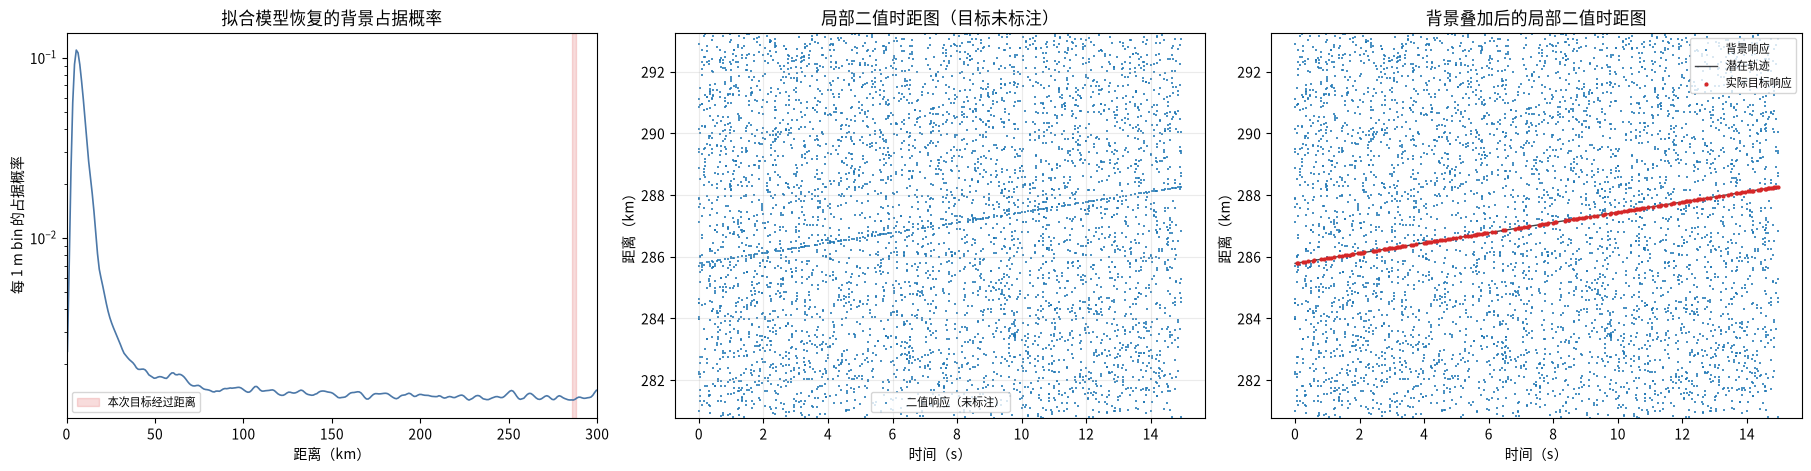

,最大 |帧间位移|（m）,帧间位移上限（m）,轨迹处背景概率中位数,轨迹处最终概率中位数,实际注入概率范围
0,8.379071,17.0,0.001261,0.600504,"(0.6, 0.6)"


In [99]:
# 一次调用即可随机生成背景和目标、显示三张图并返回完整结果。
demo = run_target_demo(model, **DEMO_CONFIG)

# 便捷别名：后续若要输入轨迹检测器，可直接使用这两个矩阵和 target 真值。
background = demo["background"]
background_with_target = demo["background_with_target"]
target = demo["target"]

## 5. 查看背景模板、目标航迹和局部叠加结果

In [88]:
# 三张图已经由 run_target_demo() 显示；完整图对象保存在 demo["figure"]。

In [89]:
# 诊断表已由 run_target_demo() 输出；完整结果保存在 demo["diagnostics"]。

## 使用说明

- 只需修改 `DEMO_CONFIG` 这一个字典，然后运行 `demo = run_target_demo(model, **DEMO_CONFIG)`；种子为 `None` 时会生成新样本，填写整数可复现。
- 设 `curve_strength=0.0` 可生成严格直线；增大 `curve_strength` 或 `max_acceleration_mps2` 会增大弯曲程度。
- `min_injection_probability` 与 `max_injection_probability` 将实际目标响应的逐帧概率限制在设定区间；当前为 $[0.60, 0.95]$。`response_multiplier` 只在该区间内调节目标强度。
- `demo["background_with_target"]` 是可直接输入轨迹检测算法的完整二值矩阵；`demo["target"]` 保存潜在轨迹、实际目标命中和生成参数。

,背景随机种子,目标随机种子,帧数,实际目标响应数,期望额外响应数,最大实际速度（m/s）,目标距离起点（km）,目标距离终点（km）
0,1058511726,3406152106,300,124,121.875,129.051,136.199,135.093


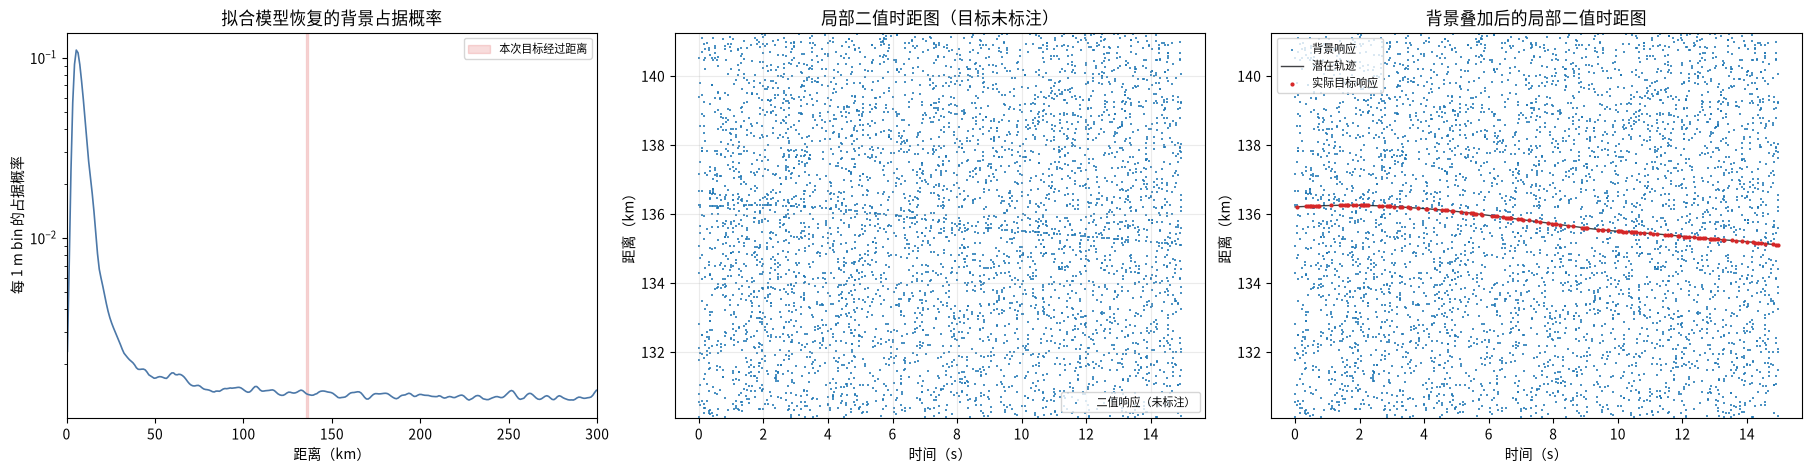

,最大 |帧间位移|（m）,帧间位移上限（m）,轨迹处背景概率中位数,轨迹处最终概率中位数,实际注入概率范围
0,6.452525,17.0,0.001358,0.407282,"(0.40463985811814424, 0.41077857141189467)"


In [102]:
# 唯一调参框：修改此字典后，运行后面的 run_target_demo 调用单元即可得到新的随机样本和三张图。
# 种子为 None 时，每次运行都会生成新的随机背景与目标；填写整数可复现。
TEST_CONFIG = {
    "background_seed": None,  # 背景随机种子；None 时每次自动随机，整数时可复现。
    "target_seed": None,      # 目标航迹与响应随机种子；None 时每次自动随机。
    "background_knobs": {  # 均为拟合模型定义的 [-1, 1] 旋钮；0 表示中点。
        "level": 0.0,       # 整体背景响应率高低。
        "decay": 0.0,       # 背景响应率随距离衰减的形状。
        "near_field": 0.0,  # 近场（约 0–10 km）背景的额外变化。
        "gain": 0.0,        # 帧间整体亮暗波动，即目标 Fano factor。
        "cluster": 0.0,     # 同帧内 1–3 m 相邻 bin 的局部聚集强度。
    },
    "target_config": {
        "frames": 300,                     # 帧数；0.05 s/帧时对应 15 s。
        "range_min_m": 10_000.0,           # 潜在轨迹允许的最小距离（m）。
        "range_max_m": 290_000.0,          # 潜在轨迹允许的最大距离（m）。
        "max_speed_mps": 340.0,            # 速度绝对值上限（m/s），即最多 17 m/帧。
        "max_acceleration_mps2": 6.0,      # 加速度尺度上限（m/s²），还会乘 curve_strength。
        "curve_strength": 10,              # 曲率强度；0 时为严格直线。
        "smooth_window_frames": 31,        # 加速度移动平均窗口（帧）；越大曲线越平滑。
        "measurement_jitter_std_m": 1.0,   # 目标响应落入 1 m bin 的测距抖动标准差（m）。
        "response_multiplier": 300.0,      # 倍率机制中的目标响应率相对背景倍率 kappa。
        "min_injection_probability": 0.35, # 实际目标响应（红点）的逐帧概率下限。
        "max_injection_probability": 0.95, # 实际目标响应（红点）的逐帧概率上限。
    },
    "margin_m": 5_000.0,             # 两张局部时距图在航迹两端保留的距离余量。
    "background_point_size": 3,       # 局部时距图中方形二值响应点的面积（pt²）。
}

# display(pd.DataFrame([
#     {"参数组": "背景旋钮", "参数": key, "取值": value}
#     for key, value in DEMO_CONFIG["background_knobs"].items()
# ]))


# 一次调用即可随机生成背景和目标、显示三张图并返回完整结果。
demo = run_target_demo(model, **TEST_CONFIG)

# 便捷别名：后续若要输入轨迹检测器，可直接使用这两个矩阵和 target 真值。
background = demo["background"]
background_with_target = demo["background_with_target"]
target = demo["target"]